# Learned Speculative Training (LST)
## Extending Speculative Weight Prediction into Chaotic Training Regimes

This notebook implements and tests LST on a small GPT-2 model.

**Make sure to select GPU runtime:** Runtime → Change runtime type → T4 GPU

## 1. Setup & Installation

In [1]:
!rm -rf LST

In [2]:
import os, sys, importlib

# Always fresh clone to avoid stale module cache issues
!rm -rf LST
!git clone https://github.com/RAVINDRA8008/Learned-Speculative-Training-LST-.git LST
%cd LST

# Remove any cached lst module so Python picks up the fresh code
if 'lst' in sys.modules:
    mods_to_remove = [k for k in sys.modules if k == 'lst' or k.startswith('lst.')]
    for m in mods_to_remove:
        del sys.modules[m]

!pip install -e . -q
!pip install wandb transformers torch tqdm matplotlib -q
!pip install datasets --upgrade -q

Cloning into 'LST'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 20 (delta 3), reused 20 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 21.13 KiB | 1.76 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/LST
  Preparing metadata (setup.py) ... done


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import time
import gc

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
GPU Memory: 42.4 GB
Using device: cuda


## 2. Configuration

**Full GPT-2 124M** on A100 with AMP (bfloat16).
Backward passes are expensive enough for LST to provide real speedup.

In [ ]:
from dataclasses import dataclass

@dataclass
class Config:
    # Model
    model_name: str = "gpt2"  # HuggingFace model name
    use_tiny: bool = False     # Full GPT-2 124M for real speedup test
    tiny_n_layers: int = 6
    tiny_n_heads: int = 4
    tiny_d_model: int = 256

    # Data
    dataset_name: str = "openwebtext"
    dataset_subset: str = None
    max_seq_len: int = 512     # Longer sequences = more expensive backward
    batch_size: int = 16       # Larger batch for A100

    # Training
    total_steps: int = 2000    # Fewer steps (each much more expensive)
    lr: float = 3e-4           # Lower LR for 124M
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    max_grad_norm: float = 1.0

    # LST Specific
    lst_enabled: bool = True
    lst_warmup_steps: int = 200    # Shorter warmup
    lst_K: int = 20                # Less frequent forced supervision
    lst_tolerance: float = 0.015   # Slightly wider tolerance
    lst_rank: int = 8              # Compact rank for factored heads
    lst_proj_dim: int = 32         # Gradient projection dim
    lst_grad_history: int = 4      # Gradient history length
    lst_draft_d_model: int = 256   # Draft model hidden dim
    lst_draft_n_heads: int = 4
    lst_draft_n_blocks: int = 2    # Fewer blocks (compact draft ~3M params)
    lst_draft_lr: float = 3e-4
    lst_adaptive_tol: bool = True

    # AMP (mixed precision) — bfloat16 on A100 for ~2x speed
    use_amp: bool = True

    # Logging
    log_interval: int = 50
    eval_interval: int = 250
    use_wandb: bool = False
    seed: int = 42

config = Config()
print("Config ready!")
print(f"  Model: {'tiny GPT-2' if config.use_tiny else 'GPT-2 124M'}")
print(f"  LST enabled: {config.lst_enabled}")
print(f"  Total steps: {config.total_steps}")
print(f"  Batch size: {config.batch_size}, Seq len: {config.max_seq_len}")
print(f"  LST warmup: {config.lst_warmup_steps} steps")
print(f"  Supervision interval K={config.lst_K}")
print(f"  AMP (bfloat16): {config.use_amp}")

Config ready!
  Model: tiny GPT-2
  LST enabled: True
  Total steps: 5000
  LST warmup: 500 steps
  Supervision interval K=10


## 3. Data Loading

We use a streaming subset of OpenWebText (or wikitext as fallback for speed).

In [5]:
from transformers import AutoTokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader, IterableDataset

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

class StreamingTextDataset(IterableDataset):
    """Streams tokenized text chunks from a HuggingFace dataset."""

    def __init__(self, tokenizer, seq_len=256, split='train'):
        self.tokenizer = tokenizer
        self.seq_len = seq_len
        self.split = split
        self.dataset = None
        self.text_key = 'text'

        # Try multiple loading strategies
        for name, config_name in [
            ('wikitext-103', 'wikitext-103-raw-v1'),
            ('wikitext-2', 'wikitext-2-raw-v1'),
        ]:
            try:
                self.dataset = load_dataset(
                    'wikitext', config_name,
                    split=split, trust_remote_code=True
                )
                print(f"Loaded {name} ({split}, {len(self.dataset)} examples)")
                break
            except Exception as e:
                print(f"{name} failed: {e}")

        # Ultimate fallback: use HF datasets with direct parquet URL
        if self.dataset is None:
            print("Trying direct parquet download...")
            try:
                import pandas as pd
                url = "https://huggingface.co/datasets/wikitext/resolve/main/wikitext-2-raw-v1/train-00000-of-00001.parquet"
                df = pd.read_parquet(url)
                self.dataset = df.to_dict('records')
                print(f"Loaded wikitext-2 via parquet ({len(self.dataset)} examples)")
            except Exception as e2:
                print(f"Parquet fallback failed: {e2}")
                print("Generating synthetic data for testing...")
                self.dataset = [{'text': f"The quick brown fox jumps over the lazy dog. Sentence number {i}. " * 10}
                               for i in range(10000)]

    def __iter__(self):
        buffer = []
        for example in self.dataset:
            text = example[self.text_key]
            if not text or len(text.strip()) < 10:
                continue
            tokens = self.tokenizer.encode(text)
            buffer.extend(tokens)

            while len(buffer) >= self.seq_len + 1:
                chunk = buffer[:self.seq_len + 1]
                buffer = buffer[self.seq_len:]
                input_ids = torch.tensor(chunk[:-1], dtype=torch.long)
                labels = torch.tensor(chunk[1:], dtype=torch.long)
                attention_mask = torch.ones_like(input_ids)
                yield {
                    'input_ids': input_ids,
                    'attention_mask': attention_mask,
                    'labels': labels,
                }

train_dataset = StreamingTextDataset(tokenizer, seq_len=config.max_seq_len, split='train')
train_loader = DataLoader(train_dataset, batch_size=config.batch_size)

# Quick test
test_batch = next(iter(train_loader))
print(f"Batch shapes: {test_batch['input_ids'].shape}")
print(f"Sample tokens: {tokenizer.decode(test_batch['input_ids'][0][:50])}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading scri

README.md: 0.00B [00:00, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00000-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00001-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Loaded wikitext-103 (train, 1801350 examples)
Batch shapes: torch.Size([8, 256])
Sample tokens:  = Valkyria Chronicles III = 
 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) ,


## 4. Model Setup

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Config

torch.manual_seed(config.seed)

if config.use_tiny:
    # Tiny GPT-2 for fast prototyping
    model_config = GPT2Config(
        vocab_size=tokenizer.vocab_size,
        n_positions=config.max_seq_len,
        n_embd=config.tiny_d_model,
        n_layer=config.tiny_n_layers,
        n_head=config.tiny_n_heads,
        resid_pdrop=0.0,
        embd_pdrop=0.0,
        attn_pdrop=0.0,
    )
    model = GPT2LMHeadModel(model_config)
    n_layer = model_config.n_layer
    n_embd = model_config.n_embd
else:
    # Full GPT-2 124M — random init for clean training comparison
    model_config = GPT2Config(
        vocab_size=tokenizer.vocab_size,
        n_positions=config.max_seq_len,
        resid_pdrop=0.0,
        embd_pdrop=0.0,
        attn_pdrop=0.0,
    )
    model = GPT2LMHeadModel(model_config)
    n_layer = model_config.n_layer
    n_embd = model_config.n_embd

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {'Tiny' if config.use_tiny else 'Full'} GPT-2")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Layers: {n_layer}")
print(f"  Hidden dim: {n_embd}")

Model: Tiny GPT-2
  Total parameters: 17,670,400
  Trainable parameters: 17,670,400
  Layers: 6
  Hidden dim: 256


## 5. Optimizer & LR Schedule

In [7]:
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.lr,
    weight_decay=config.weight_decay,
    betas=(0.9, 0.999),
)

warmup_steps = int(config.total_steps * config.warmup_ratio)
warmup_scheduler = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=config.total_steps - warmup_steps, eta_min=config.lr * 0.1)
lr_scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_steps])

print(f"Optimizer: AdamW (lr={config.lr}, wd={config.weight_decay})")
print(f"LR Schedule: Linear warmup ({warmup_steps} steps) + Cosine decay")

Optimizer: AdamW (lr=0.0005, wd=0.01)
LR Schedule: Linear warmup (500 steps) + Cosine decay


## 6. Initialize LST Trainer

In [ ]:
from lst.trainer import LSTTrainer

lst_trainer = LSTTrainer(
    model=model,
    optimizer=optimizer,
    K=config.lst_K,
    tolerance=config.lst_tolerance,
    warmup_steps=config.lst_warmup_steps,
    grad_history_len=config.lst_grad_history,
    proj_dim=config.lst_proj_dim,
    rank=config.lst_rank,
    total_steps=config.total_steps,
    draft_lr=config.lst_draft_lr,
    d_model=config.lst_draft_d_model,
    n_heads=config.lst_draft_n_heads,
    n_blocks=config.lst_draft_n_blocks,
    adaptive_tolerance=config.lst_adaptive_tol,
    max_grad_norm=config.max_grad_norm,
    use_amp=config.use_amp,
)

print(f"\nLST Trainer initialized!")
print(f"  Draft model: {lst_trainer.draft.count_parameters():,} params")
print(f"  Target layers for speculation: {len(lst_trainer.target_layers)}")
print(f"  Feature dim: {lst_trainer.feat_extractor.feat_dim}")
print(f"  Warmup: {config.lst_warmup_steps} steps")
print(f"  Supervision interval K={config.lst_K}")
print(f"  Tolerance: {config.lst_tolerance} (adaptive={config.lst_adaptive_tol})")
print(f"  AMP enabled: {config.use_amp}")

[LST] Target model has 26 2D parameter layers for speculative prediction
[LST] Total trainable params: 17,670,400


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[LST] Draft model parameters: 624,942,880

LST Trainer initialized!
  Draft model: 624,942,880 params
  Target layers for speculation: 26
  Feature dim: 134
  Warmup: 500 steps
  Supervision interval K=10
  Tolerance: 0.01 (adaptive=True)


## 7. Training Loop

In [9]:
# ============================================================
#  LST TRAINING LOOP
# ============================================================

# Tracking
losses = []
acceptance_rates = []
draft_losses = []
tolerances = []
accepted_flags = []
step_times = []
steps_done = 0

model.train()
pbar = tqdm(total=config.total_steps, desc="LST Training")

start_time = time.time()

for batch in train_loader:
    if steps_done >= config.total_steps:
        break

    step_start = time.time()

    # Current LR
    current_lr = optimizer.param_groups[0]['lr']

    # LST step
    result = lst_trainer.step_batch(batch, lr=current_lr)

    # LR scheduler step (only for non-speculative-accepted steps)
    if result.get('accepted') is not True:
        lr_scheduler.step()

    step_time = time.time() - step_start
    steps_done += 1

    # Record metrics
    losses.append(result['loss'])
    step_times.append(step_time)

    if result.get('accepted') is not None:
        accepted_flags.append(1 if result['accepted'] else 0)
    if result.get('acceptance_rate') is not None:
        acceptance_rates.append(result['acceptance_rate'])
    if result.get('draft_loss') is not None:
        draft_losses.append(result['draft_loss'])
    if result.get('tolerance') is not None:
        tolerances.append(result['tolerance'])

    # Logging
    if steps_done % config.log_interval == 0:
        avg_loss = np.mean(losses[-config.log_interval:])
        avg_time = np.mean(step_times[-config.log_interval:])
        phase = result.get('phase', 'unknown')

        log_msg = f"Step {steps_done}/{config.total_steps} | Loss: {avg_loss:.4f} | LR: {current_lr:.6f} | Phase: {phase} | {avg_time*1000:.1f}ms/step"

        if acceptance_rates:
            log_msg += f" | Accept: {acceptance_rates[-1]:.1%}"
        if result.get('tolerance') is not None:
            log_msg += f" | Tol: {result['tolerance']:.4f}"

        tqdm.write(log_msg)

    pbar.update(1)

pbar.close()
total_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"Training complete!")
print(f"  Total steps:  {steps_done}")
print(f"  Total time:   {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"  Final loss:   {np.mean(losses[-50:]):.4f}")
print(f"  Avg ms/step:  {np.mean(step_times)*1000:.1f}")
if acceptance_rates:
    print(f"  Final acceptance rate: {acceptance_rates[-1]:.1%}")
    print(f"  Total accepted: {lst_trainer.verifier.total_accepted}")
    print(f"  Total speculative: {lst_trainer.verifier.total_speculative}")
print(f"{'='*60}")

LST Training:   0%|          | 0/5000 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Step 50/5000 | Loss: 10.3720 | LR: 0.000054 | Phase: warmup | 220.5ms/step
Step 100/5000 | Loss: 9.4886 | LR: 0.000103 | Phase: warmup | 121.8ms/step
Step 150/5000 | Loss: 8.2926 | LR: 0.000153 | Phase: warmup | 121.6ms/step
Step 200/5000 | Loss: 7.5952 | LR: 0.000202 | Phase: warmup | 122.1ms/step
Step 250/5000 | Loss: 7.4153 | LR: 0.000252 | Phase: warmup | 121.8ms/step
Step 300/5000 | Loss: 7.3059 | LR: 0.000301 | Phase: warmup | 122.1ms/step
Step 350/5000 | Loss: 7.3408 | LR: 0.000351 | Phase: warmup | 122.0ms/step
Step 400/5000 | Loss: 7.3524 | LR: 0.000400 | Phase: warmup | 121.5ms/step
Step 450/5000 | Loss: 7.2034 | LR: 0.000450 | Phase: warmup | 121.6ms/step
Step 500/5000 | Loss: 7.3321 | LR: 0.000499 | Phase: warmup | 121.3ms/step
Step 550/5000 | Loss: 7.2976 | LR: 0.000500 | Phase: forced_supervision | 68.1ms/step | Accept: 75.6%
Step 600/5000 | Loss: 7.2607 | LR: 0.000500 | Phase: forced_supervision | 67.2ms/step | Accept: 75.6%
Step 650/5000 | Loss: 7.3127 | LR: 0.000500 | 

## 8. Baseline Comparison (Standard Training)

In [ ]:
# ============================================================
#  BASELINE: Standard training (no LST) for comparison
# ============================================================

# Re-initialize model with same seed
torch.manual_seed(config.seed)
if config.use_tiny:
    baseline_model = GPT2LMHeadModel(model_config).to(device)
else:
    baseline_model = GPT2LMHeadModel(model_config).to(device)

baseline_optimizer = torch.optim.AdamW(
    baseline_model.parameters(), lr=config.lr,
    weight_decay=config.weight_decay, betas=(0.9, 0.999),
)
baseline_warmup = LinearLR(baseline_optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)
baseline_cosine = CosineAnnealingLR(baseline_optimizer, T_max=config.total_steps - warmup_steps, eta_min=config.lr * 0.1)
baseline_lr_sched = SequentialLR(baseline_optimizer, schedulers=[baseline_warmup, baseline_cosine], milestones=[warmup_steps])

# Reload data
baseline_dataset = StreamingTextDataset(tokenizer, seq_len=config.max_seq_len, split='train')
baseline_loader = DataLoader(baseline_dataset, batch_size=config.batch_size)

baseline_losses = []
baseline_times = []
baseline_steps = 0

baseline_model.train()
pbar = tqdm(total=config.total_steps, desc="Baseline Training")
baseline_start = time.time()

for batch in baseline_loader:
    if baseline_steps >= config.total_steps:
        break

    step_start = time.time()

    batch = {k: v.to(device) for k, v in batch.items() if isinstance(v, torch.Tensor)}
    baseline_optimizer.zero_grad()
    with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=config.use_amp):
        output = baseline_model(**batch)
        loss = output.loss
    loss.backward()
    torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), config.max_grad_norm)
    baseline_optimizer.step()
    baseline_lr_sched.step()

    step_time = time.time() - step_start
    baseline_steps += 1
    baseline_losses.append(loss.item())
    baseline_times.append(step_time)

    if baseline_steps % config.log_interval == 0:
        avg_loss = np.mean(baseline_losses[-config.log_interval:])
        avg_time = np.mean(baseline_times[-config.log_interval:])
        tqdm.write(f"Baseline Step {baseline_steps}/{config.total_steps} | Loss: {avg_loss:.4f} | {avg_time*1000:.1f}ms/step")

    pbar.update(1)

pbar.close()
baseline_total_time = time.time() - baseline_start

print(f"\nBaseline complete!")
print(f"  Total time: {baseline_total_time:.1f}s ({baseline_total_time/60:.1f} min)")
print(f"  Final loss: {np.mean(baseline_losses[-50:]):.4f}")
print(f"  Avg ms/step: {np.mean(baseline_times)*1000:.1f}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded wikitext-103 (train, 1801350 examples)


Baseline Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Baseline Step 50/5000 | Loss: 10.3720 | 16.5ms/step
Baseline Step 100/5000 | Loss: 9.4886 | 16.6ms/step
Baseline Step 150/5000 | Loss: 8.2926 | 16.6ms/step
Baseline Step 200/5000 | Loss: 7.5952 | 16.2ms/step
Baseline Step 250/5000 | Loss: 7.4153 | 16.2ms/step
Baseline Step 300/5000 | Loss: 7.3059 | 16.2ms/step
Baseline Step 350/5000 | Loss: 7.3408 | 16.4ms/step
Baseline Step 400/5000 | Loss: 7.3524 | 17.1ms/step
Baseline Step 450/5000 | Loss: 7.2034 | 17.3ms/step
Baseline Step 500/5000 | Loss: 7.3321 | 16.3ms/step
Baseline Step 550/5000 | Loss: 7.2146 | 16.1ms/step
Baseline Step 600/5000 | Loss: 7.1927 | 16.3ms/step
Baseline Step 650/5000 | Loss: 7.2591 | 16.4ms/step
Baseline Step 700/5000 | Loss: 7.1082 | 16.4ms/step
Baseline Step 750/5000 | Loss: 7.1585 | 16.7ms/step
Baseline Step 800/5000 | Loss: 7.1828 | 17.1ms/step
Baseline Step 850/5000 | Loss: 7.0863 | 16.3ms/step
Baseline Step 900/5000 | Loss: 7.0848 | 16.3ms/step
Baseline Step 950/5000 | Loss: 7.1445 | 16.3ms/step
Baseline Ste

## 9. Results & Visualization

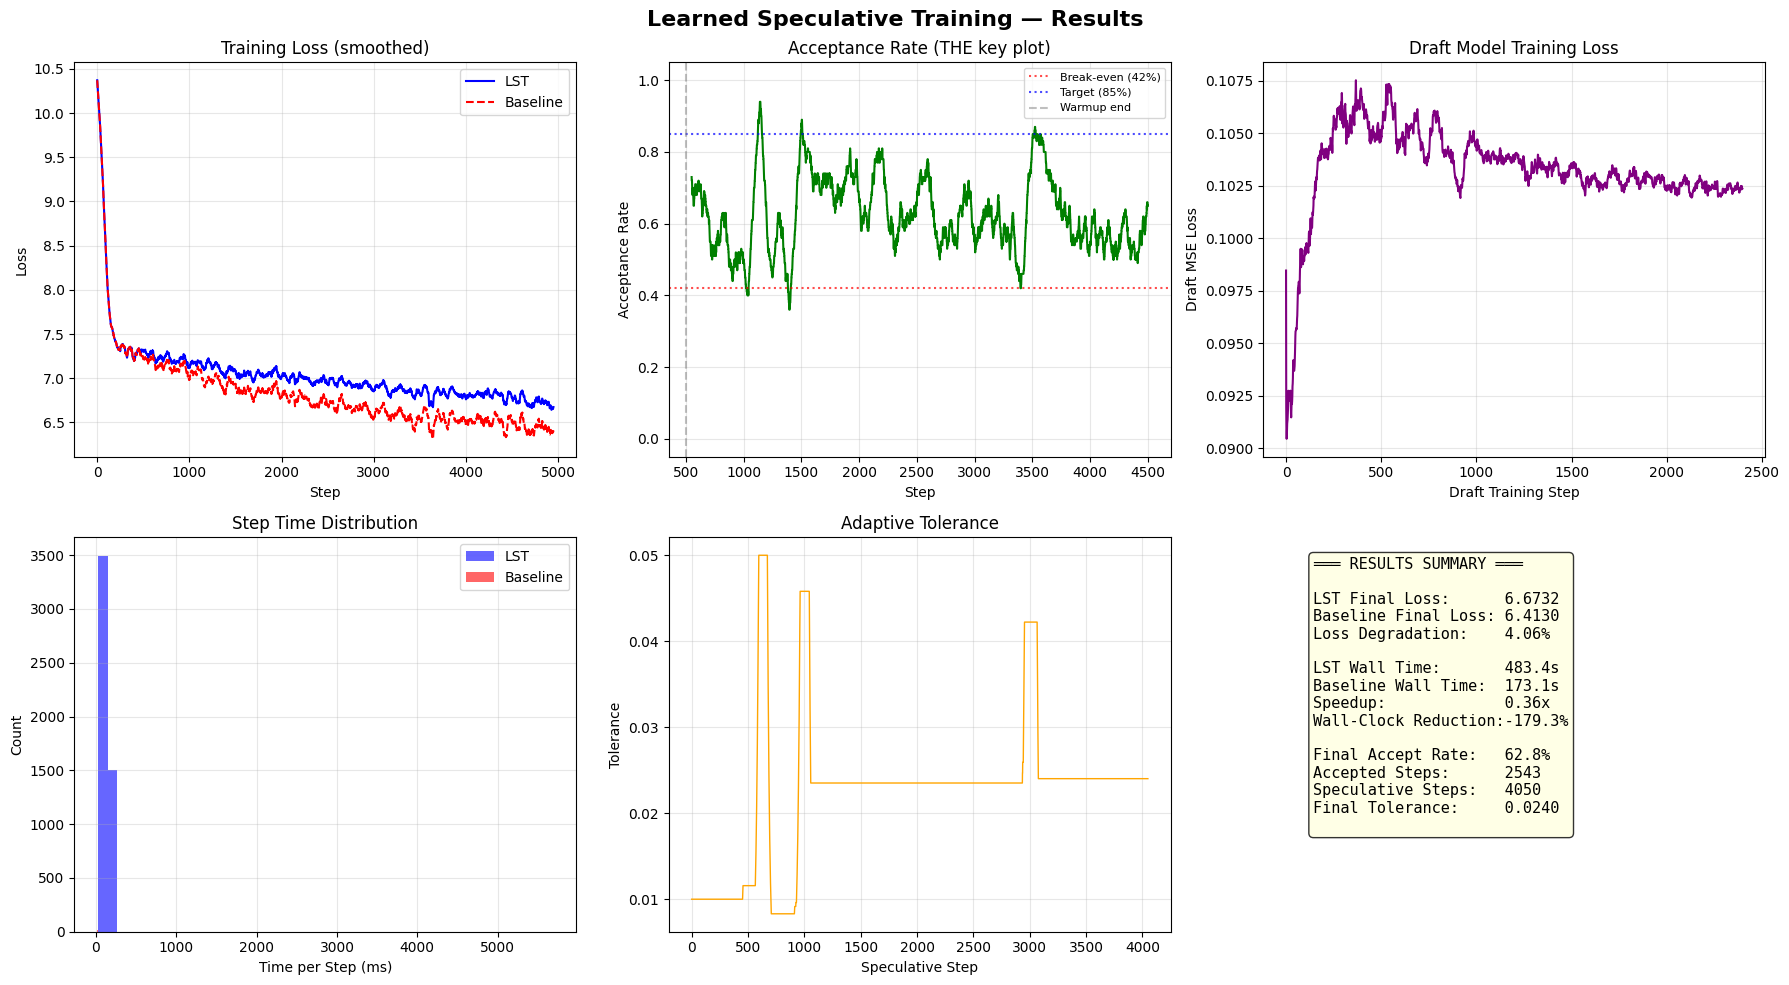

Results saved to lst_results.png


In [11]:
# ============================================================
#  PLOTS: Loss curves, acceptance rate, speedup analysis
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Learned Speculative Training — Results', fontsize=16, fontweight='bold')

# --- Plot 1: Training Loss Comparison ---
ax = axes[0, 0]
window = 50
if len(losses) > window:
    smoothed_lst = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax.plot(smoothed_lst, label='LST', color='blue', linewidth=1.5)
if len(baseline_losses) > window:
    smoothed_base = np.convolve(baseline_losses, np.ones(window)/window, mode='valid')
    ax.plot(smoothed_base, label='Baseline', color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Training Loss (smoothed)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Acceptance Rate Over Training ---
ax = axes[0, 1]
if accepted_flags:
    # Compute rolling acceptance rate
    rolling_window = 100
    if len(accepted_flags) > rolling_window:
        rolling_accept = np.convolve(
            accepted_flags, np.ones(rolling_window)/rolling_window, mode='valid'
        )
        x_offset = config.lst_warmup_steps + rolling_window // 2
        ax.plot(range(x_offset, x_offset + len(rolling_accept)), rolling_accept,
                color='green', linewidth=1.5)
    ax.axhline(y=0.42, color='red', linestyle=':', alpha=0.7, label='Break-even (42%)')
    ax.axhline(y=0.85, color='blue', linestyle=':', alpha=0.7, label='Target (85%)')
    ax.axvline(x=config.lst_warmup_steps, color='gray', linestyle='--', alpha=0.5, label='Warmup end')
ax.set_xlabel('Step')
ax.set_ylabel('Acceptance Rate')
ax.set_title('Acceptance Rate (THE key plot)')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 3: Draft Model Loss ---
ax = axes[0, 2]
if draft_losses:
    dl_window = min(50, len(draft_losses))
    if len(draft_losses) > dl_window:
        smoothed_dl = np.convolve(draft_losses, np.ones(dl_window)/dl_window, mode='valid')
        ax.plot(smoothed_dl, color='purple', linewidth=1.5)
    else:
        ax.plot(draft_losses, color='purple', linewidth=1.5)
ax.set_xlabel('Draft Training Step')
ax.set_ylabel('Draft MSE Loss')
ax.set_title('Draft Model Training Loss')
ax.grid(True, alpha=0.3)

# --- Plot 4: Step Time Comparison ---
ax = axes[1, 0]
bins = 50
if step_times:
    ax.hist(np.array(step_times)*1000, bins=bins, alpha=0.6, color='blue', label='LST')
if baseline_times:
    ax.hist(np.array(baseline_times)*1000, bins=bins, alpha=0.6, color='red', label='Baseline')
ax.set_xlabel('Time per Step (ms)')
ax.set_ylabel('Count')
ax.set_title('Step Time Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 5: Tolerance Adaptation ---
ax = axes[1, 1]
if tolerances:
    ax.plot(tolerances, color='orange', linewidth=1.0)
ax.set_xlabel('Speculative Step')
ax.set_ylabel('Tolerance')
ax.set_title('Adaptive Tolerance')
ax.grid(True, alpha=0.3)

# --- Plot 6: Summary Stats ---
ax = axes[1, 2]
ax.axis('off')
summary_text = (
    f"═══ RESULTS SUMMARY ═══\n\n"
    f"LST Final Loss:      {np.mean(losses[-50:]):.4f}\n"
    f"Baseline Final Loss: {np.mean(baseline_losses[-50:]):.4f}\n"
    f"Loss Degradation:    {((np.mean(losses[-50:]) - np.mean(baseline_losses[-50:])) / np.mean(baseline_losses[-50:])) * 100:.2f}%\n\n"
    f"LST Wall Time:       {total_time:.1f}s\n"
    f"Baseline Wall Time:  {baseline_total_time:.1f}s\n"
    f"Speedup:             {baseline_total_time / total_time:.2f}x\n"
    f"Wall-Clock Reduction:{(1 - total_time/baseline_total_time)*100:.1f}%\n\n"
)
if acceptance_rates:
    summary_text += (
        f"Final Accept Rate:   {acceptance_rates[-1]:.1%}\n"
        f"Accepted Steps:      {lst_trainer.verifier.total_accepted}\n"
        f"Speculative Steps:   {lst_trainer.verifier.total_speculative}\n"
        f"Final Tolerance:     {lst_trainer.verifier.tolerance:.4f}\n"
    )
ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('lst_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved to lst_results.png")

## 10. Detailed Analysis

In [12]:
# ============================================================
#  ANALYSIS: Training regime breakdown
# ============================================================

print("\n" + "="*60)
print("TRAINING REGIME ANALYSIS")
print("="*60)

if accepted_flags:
    flags = np.array(accepted_flags)

    # Split into training phases
    # Chaotic: first 1/3 of speculative steps
    # Transition: middle 1/3
    # Stable: final 1/3
    n = len(flags)
    third = n // 3

    chaotic_rate = flags[:third].mean() if third > 0 else 0
    transition_rate = flags[third:2*third].mean() if third > 0 else 0
    stable_rate = flags[2*third:].mean() if third > 0 else 0

    print(f"\nAcceptance Rate by Training Phase:")
    print(f"  Chaotic (early):     {chaotic_rate:.1%}  (Leap+Verify target: ~9%)")
    print(f"  Transition (middle): {transition_rate:.1%}  (Leap+Verify target: ~20-30%)")
    print(f"  Stable (late):       {stable_rate:.1%}  (Leap+Verify target: ~37%)")
    print(f"  Overall:             {flags.mean():.1%}")

    # Cost analysis
    p = flags.mean()
    K = config.lst_K
    cost_per_step = p * 1.075 + (1-p) * 4.125 + (1/K) * 3.0
    baseline_cost = 3.0
    theoretical_speedup = baseline_cost / cost_per_step

    print(f"\nTheoretical Cost Analysis (from paper's model):")
    print(f"  Acceptance rate p = {p:.3f}")
    print(f"  Cost per step: {cost_per_step:.3f} (baseline: {baseline_cost:.3f})")
    print(f"  Theoretical speedup: {theoretical_speedup:.2f}x")
    print(f"  Theoretical wall-clock reduction: {(1 - 1/theoretical_speedup)*100:.1f}%")

    print(f"\nActual Measured:")
    print(f"  LST total time:      {total_time:.1f}s")
    print(f"  Baseline total time:  {baseline_total_time:.1f}s")
    print(f"  Measured speedup:     {baseline_total_time/total_time:.2f}x")
    print(f"  Measured reduction:   {(1 - total_time/baseline_total_time)*100:.1f}%")
else:
    print("No speculative steps recorded (still in warmup?)")

# Draft model analysis
if draft_losses:
    print(f"\nDraft Model Analysis:")
    print(f"  Initial draft loss: {draft_losses[0]:.6f}")
    print(f"  Final draft loss:   {draft_losses[-1]:.6f}")
    if draft_losses[0] > 0:
        print(f"  Improvement:        {(1 - draft_losses[-1]/draft_losses[0])*100:.1f}%")

print("\n" + "="*60)


TRAINING REGIME ANALYSIS

Acceptance Rate by Training Phase:
  Chaotic (early):     63.0%  (Leap+Verify target: ~9%)
  Transition (middle): 64.4%  (Leap+Verify target: ~20-30%)
  Stable (late):       61.0%  (Leap+Verify target: ~37%)
  Overall:             62.8%

Theoretical Cost Analysis (from paper's model):
  Acceptance rate p = 0.628
  Cost per step: 2.510 (baseline: 3.000)
  Theoretical speedup: 1.20x
  Theoretical wall-clock reduction: 16.3%

Actual Measured:
  LST total time:      483.4s
  Baseline total time:  173.1s
  Measured speedup:     0.36x
  Measured reduction:   -179.3%

Draft Model Analysis:
  Initial draft loss: 0.418457
  Final draft loss:   0.101168
  Improvement:        75.8%



## 11. Save Results

In [13]:
import json

results = {
    'config': {
        'model': 'tiny_gpt2' if config.use_tiny else 'gpt2_124m',
        'total_steps': config.total_steps,
        'lst_warmup': config.lst_warmup_steps,
        'lst_K': config.lst_K,
        'lst_rank': config.lst_rank,
        'lr': config.lr,
    },
    'lst': {
        'final_loss': float(np.mean(losses[-50:])),
        'total_time_s': total_time,
        'acceptance_rate': float(acceptance_rates[-1]) if acceptance_rates else 0,
        'total_accepted': lst_trainer.verifier.total_accepted,
        'total_speculative': lst_trainer.verifier.total_speculative,
    },
    'baseline': {
        'final_loss': float(np.mean(baseline_losses[-50:])),
        'total_time_s': baseline_total_time,
    },
    'comparison': {
        'speedup': baseline_total_time / total_time,
        'wall_clock_reduction_pct': (1 - total_time / baseline_total_time) * 100,
        'loss_degradation_pct': ((np.mean(losses[-50:]) - np.mean(baseline_losses[-50:])) / np.mean(baseline_losses[-50:])) * 100,
    }
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to results.json")
print(json.dumps(results, indent=2))

Results saved to results.json
{
  "config": {
    "model": "tiny_gpt2",
    "total_steps": 5000,
    "lst_warmup": 500,
    "lst_K": 10,
    "lst_rank": 32,
    "lr": 0.0005
  },
  "lst": {
    "final_loss": 6.6731619548797605,
    "total_time_s": 483.384822845459,
    "acceptance_rate": 0.6279012345679013,
    "total_accepted": 2543,
    "total_speculative": 4050
  },
  "baseline": {
    "final_loss": 6.413037824630737,
    "total_time_s": 173.07734775543213
  },
  "comparison": {
    "speedup": 0.35805292093493385,
    "wall_clock_reduction_pct": -179.28832346593876,
    "loss_degradation_pct": 4.05617645431557
  }
}
